# World Coffee Prices: Arabica vs Robusta (1990–2025)

**Source:** World Bank Commodity Price Data (The Pink Sheet), *CMO Historical Data – Annual*, sheet **Annual Prices (Nominal)**, updated September 02, 2026.
Series: *Coffee, Arabica* and *Coffee, Robusta* (ICO indicator prices, $/kg).

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = Path("CMO-Historical-Data-Annual.xlsx")
YEAR_START, YEAR_END = 1990, 2025

# Row 7 = commodity names, data starts on row 9
raw = pd.read_excel(DATA_FILE, sheet_name="Annual Prices (Nominal)", header=None)
cols = [0] + [i for i, n in enumerate(raw.iloc[6]) if n in ("Coffee, Arabica", "Coffee, Robusta")]
df = raw.iloc[8:, cols]
df.columns = ["year", "Coffee, Arabica", "Coffee, Robusta"]
df = df.apply(pd.to_numeric, errors="coerce").dropna(subset=["year"]).astype({"year": int})
df = df[df["year"].between(YEAR_START, YEAR_END)]

coffee = df.melt(id_vars="year", var_name="series", value_name="price_usd_per_kg")
coffee.head()

,year,series,price_usd_per_kg
0,1990,"Coffee, Arabica",1.97
1,1991,"Coffee, Arabica",1.87
2,1992,"Coffee, Arabica",1.41
3,1993,"Coffee, Arabica",1.56
4,1994,"Coffee, Arabica",3.31


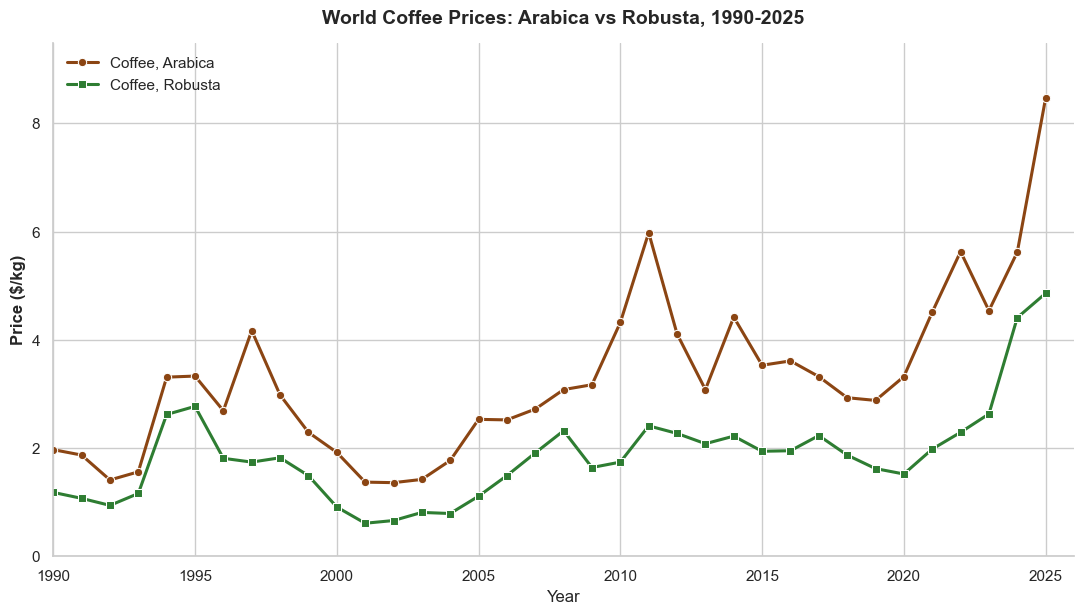

In [19]:
PALETTE = {"Coffee, Arabica": "#8B4513", "Coffee, Robusta": "#2E7D32"}
MARKERS = {"Coffee, Arabica": "o", "Coffee, Robusta": "s"}

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.lineplot(data=coffee, x="year", y="price_usd_per_kg", hue="series", style="series",
             palette=PALETTE, markers=MARKERS, dashes=False, linewidth=2.2, markersize=6, ax=ax)

ax.set_title(f"World Coffee Prices: Arabica vs Robusta, {YEAR_START}-{YEAR_END}",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Price ($/kg)",fontweight="bold")
ax.set_xticks(range(YEAR_START, YEAR_END + 1, 5))
ax.set_xlim(YEAR_START, YEAR_END + 1)
ax.set_ylim(0, coffee["price_usd_per_kg"].max() * 1.12)
ax.legend(title=None, frameon=False, loc="upper left")
sns.despine()

fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("coffee_world_price_1990_2025.png", dpi=300, bbox_inches="tight")
plt.show()